<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Structural breaks: GSADF / BSADF for multiple bubbles
    </h1>
  </div>
</div>

De Prado's **single-window SADF** (AFML ch.17) fixes the test window's
start at the sample origin. When a series contains *more than one* explosive
episode the early sample dilutes the later test, so several bubbles mask one
another and SADF collapses them to about one. **GSADF/BSADF** (Phillips-Shi-Yu
2015) varies *both* window endpoints; the backward BSADF sequence dates each
origination and collapse, recovering and counting every episode.

*Baseline (SADF) -> where it breaks (multiple bubbles) -> GSADF/BSADF -> when to use.*

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))   # the pinned notebook environment

using Random, Statistics, Plots
gr()
theme(:default)                            # theme-adaptive figures (legible on light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)
using RiskLabAI.Features: get_sadf_sequence, get_bsadf_sequence, get_gsadf_statistic,
    get_bubble_episodes, psy_minimum_window, simulate_psy_critical_values

  Activating project at `C:\risklab\risklabai\Notebooks.jl`


## 1. A series with TWO explosive episodes
A random walk with two embedded explosive (mildly super-unit-root) runs.

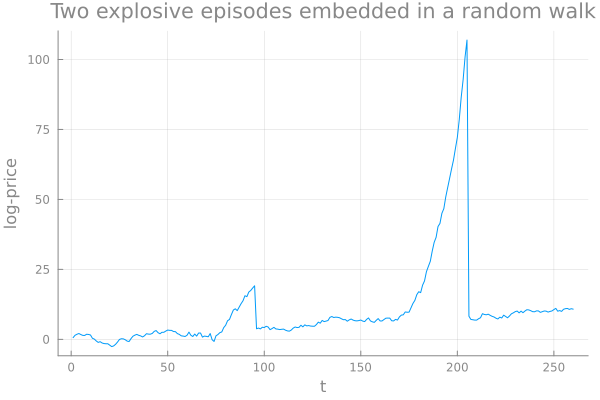

In [2]:
rng = MersenneTwister(7)
T = 260
y = cumsum(randn(rng, T)) .* 0.5
for t in 60:95        # bubble 1
    y[t] = 1.08 * y[t-1] + randn(rng)
end
for t in 170:205      # bubble 2
    y[t] = 1.08 * y[t-1] + randn(rng)
end
plot(y; legend = false, lw = 1, xlabel = "t", ylabel = "log-price",
     title = "Two explosive episodes embedded in a random walk")

## 2. SADF vs BSADF sequences
The forward-expanding SADF is anchored at the origin; the backward-sup BSADF
tests each endpoint on its own sub-sample.

min window = 32   GSADF statistic = 23.108


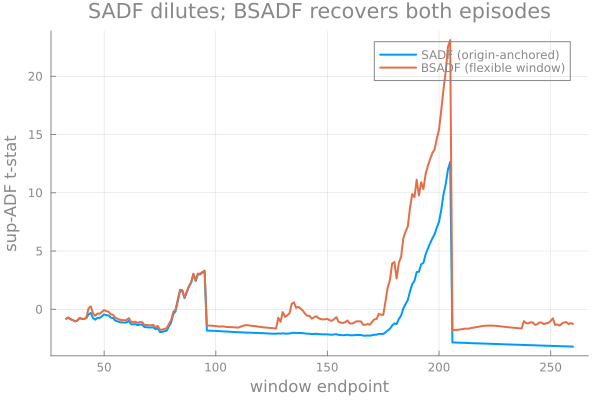

In [3]:
nmin = psy_minimum_window(T)
sadf = get_sadf_sequence(y, nmin, "c", 0)
bsadf = get_bsadf_sequence(y, nmin, "c", 0)
gsadf = get_gsadf_statistic(y, nmin, "c", 0)
println("min window = ", nmin, "   GSADF statistic = ", round(gsadf, digits = 3))

plot(sadf.index, sadf.values; label = "SADF (origin-anchored)", lw = 2,
     xlabel = "window endpoint", ylabel = "sup-ADF t-stat",
     title = "SADF dilutes; BSADF recovers both episodes")
plot!(bsadf.index, bsadf.values; label = "BSADF (flexible window)", lw = 2)

## 3. Date-stamping with simulated finite-sample critical values
Critical values are simulated under the random-walk null (the statistics are
pivotal). Episodes are maximal runs where BSADF exceeds its critical value.

GSADF 95% critical value = 1.9
Detected episodes (origination, collapse): [(88, 96), (178, 206)]


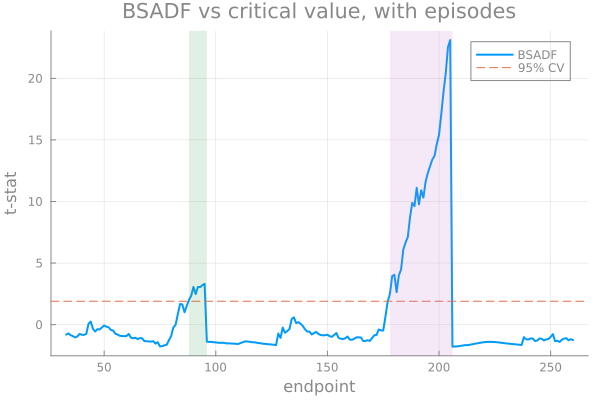

In [4]:
cv = simulate_psy_critical_values(T, nmin; n_simulations = 200, rng = MersenneTwister(0))
episodes = get_bubble_episodes(bsadf.index, bsadf.values, cv.gsadf_global_cv; min_duration = 3)
println("GSADF 95% critical value = ", round(cv.gsadf_global_cv, digits = 3))
println("Detected episodes (origination, collapse): ", episodes)

plot(bsadf.index, bsadf.values; label = "BSADF", lw = 2, xlabel = "endpoint",
     ylabel = "t-stat", title = "BSADF vs critical value, with episodes")
hline!([cv.gsadf_global_cv]; label = "95% CV", ls = :dash)
for (a, b) in episodes
    vspan!([a, b]; alpha = 0.15, label = "")
end
plot!()

## When to use / when NOT (from `appraisals/05_verdict.md`)
**Prefer GSADF/BSADF over single-window SADF when a series may contain more than
one explosive episode** (it recovers and counts each). For a single suspected
bubble, SADF is at least as good. Use seasonally-adjusted data and the simulated
finite-sample critical values; **GSADF over-flags strongly trending or seasonal
series and is mildly oversized in large samples**, so treat broad flags
cautiously.